<div align="center">

<div align="center">
<img src="../images/logo_adela.jpg" alt="logo" width="800"/>
</div>

## ADeLA 2025

## Región de atacama, Chile

</div>

# https://github.com/stevenalfonso/ADeLA-2025

# Outline

* The membership problem
* Unsupervised techniques
    * DBSCAN
    * HDBSCAN

<div align="center">

# The membership problem

<div align="center">
<img src="../images/membership.png" alt="membership" width="700"/>
</div>

</div>

* Proper motions (the classic probability approach)
* Machine learning (unsupervised techniques on astrometric data)
    * $\alpha$, $\delta$, $\mu_{\alpha}$, $\mu_{\delta}$, $\varpi$, $v_{\text{rad}}$

### Distance Metrics for DBSCAN & HDBSCAN  

- **Euclidean Distance (`'euclidean'`)**  
  The straight-line distance between two points in an n-dimensional space:  
  $$
  d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
  $$  

- **Manhattan Distance (`'manhattan'`)**  
  Also called **Taxicab** or **L1 distance**, it sums the absolute differences along each dimension:  
  $$
  d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
  $$  

- **Minkowski Distance (`'minkowski'`)**  
  A generalization of both Euclidean and Manhattan distances:  
  $$
  d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}
  $$  
  - If **p = 1**, it becomes the **Manhattan Distance**.  
  - If **p = 2**, it becomes the **Euclidean Distance**.  

- **Mahalanobis Distance (`'mahalanobis'`)**  
  Accounts for correlations between variables and scales differently in different directions:  
  $$
  d_M(x, y) = \sqrt{(x - y)^T S^{-1} (x - y)}
  $$  
  where **S** is the covariance matrix of the data.  


<div align="center">

# DBSCAN

DBSCAN identifies overdensities by computing distances between points in the data set. It mainly depends on two hyperparameters: minPts and 𝜖 (Ester +1996)

<div align="center">
<img src="../images/dbscan.png" alt="membership" width="600"/>
</div>

Schematic representation with minPts = 3 (Castro-Ginard+2018)

</div>


Points are classified as: 
- <span style="color:green">Core points</span>
- <span style="color:blue">Border points</span>
- <span style="color:red">Outliers</span>


### DBSCAN Hyperparameters  

- **`eps` (ϵ - Epsilon):**  
  Defines the maximum distance between two points to be considered neighbors.  

- **`min_samples`:**  
  The minimum number of points (including the core point) required to form a dense region.  

- **`metric`:**  
  The distance metric used to measure the similarity between points (default is Euclidean distance).  

In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm
from sklearn.cluster import DBSCAN

In [3]:
#df = pd.read_csv('Coma_Cluster_GAIA_DR3.csv') # full gaia sample for one cluster
x = pd.read_csv('Coma_Cluster_GAIA_DR3.csv')
df = pd.read_csv('Coma_Cluster_GAIA_DR3.csv').query('parallax_over_error > 10')
print((df.columns))
print('ra=',df["ra"].min(), df["ra"].max())
print('dec=',df["dec"].min(), df["dec"].max())
print('numeroestrellas= ',len(df))

print((x.columns))
print('ra=',x["ra"].min(), x["ra"].max())
print('dec=',x["dec"].min(), x["dec"].max())
print('numeroestrellas= ',len(x))



Index(['solution_id', 'designation', 'source_id', 'random_index', 'ref_epoch',
       'ra', 'ra_error', 'dec', 'dec_error', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'ra_dec_corr', 'ra_parallax_corr', 'ra_pmra_corr',
       'ra_pmdec_corr', 'dec_parallax_corr', 'dec_pmra_corr', 'dec_pmdec_corr',
       'parallax_pmra_corr', 'parallax_pmdec_corr', 'pmra_pmdec_corr',
       'astrometric_n_obs_al', 'astrometric_n_obs_ac',
       'astrometric_n_good_obs_al', 'astrometric_n_bad_obs_al',
       'astrometric_gof_al', 'astrometric_chi2_al', 'astrometric_excess_noise',
       'astrometric_excess_noise_sig', 'astrometric_params_solved',
       'astrometric_primary_flag', 'nu_eff_used_in_astrometry', 'pseudocolour',
       'pseudocolour_error', 'ra_pseudocolour_corr', 'dec_pseudocolour_corr',
       'parallax_pseudocolour_corr', 'pmra_pseudocolour_corr',
       'pmdec_pseudocolour_corr', 'astrometric_matched_transits',
 

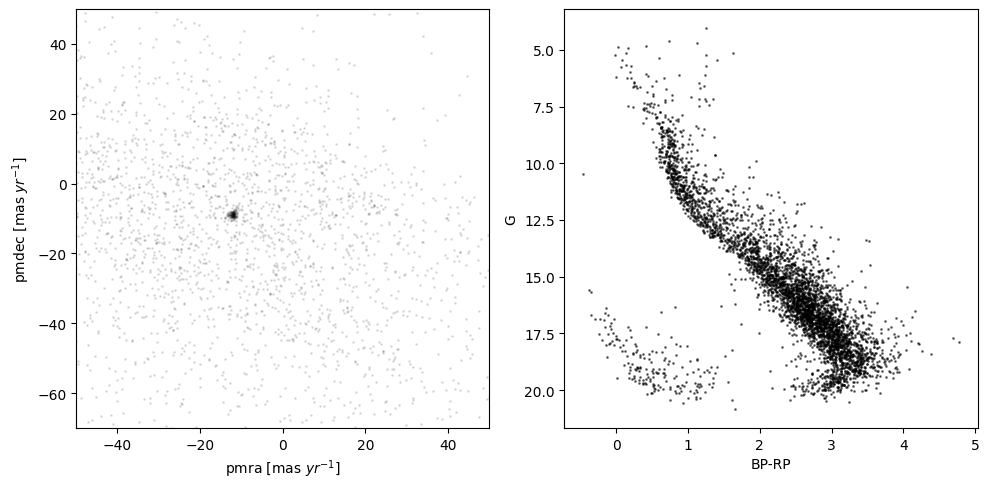

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(df['pmra'], df['pmdec'], s=1, alpha=0.1, c='k')
ax[0].set_xlabel("pmra [mas $yr^{-1}$]")
ax[0].set_ylabel("pmdec [mas $yr^{-1}$]")
ax[0].set_xlim(-50, 50)
ax[0].set_ylim(-70, 50)

ax[1].scatter(df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'], df['phot_g_mean_mag'], s=1, alpha=0.5, c='k')
ax[1].set_xlabel("BP-RP")
ax[1].set_ylabel("G")
ax[1].invert_yaxis()
fig.tight_layout()

In [5]:
clustering_on = ['pmra','pmdec','parallax']

data = df[clustering_on]
data = RobustScaler().fit_transform(data)

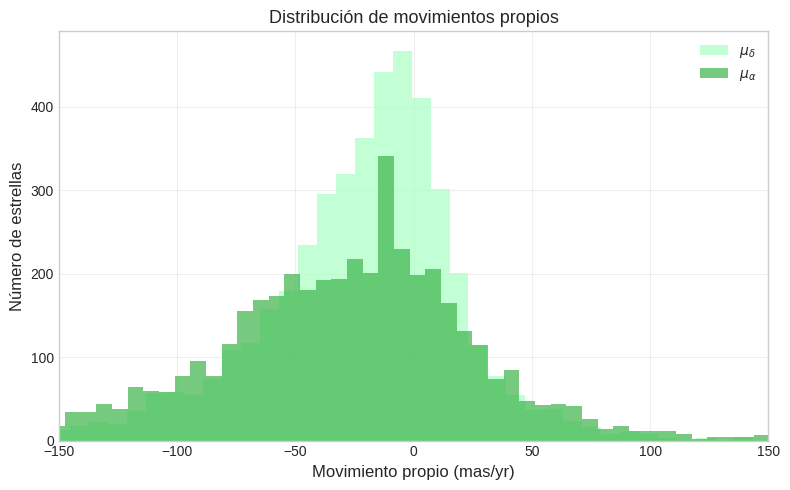

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df['pmdec'], bins=200, color='#aaffc3', alpha=0.7, label=r'$\mu_{\delta}$')
plt.hist(df['pmra'], bins=200, color='#3cb44b', alpha=0.7, label=r'$\mu_{\alpha}$')
plt.xlim(-150,150)
plt.xlabel('Movimiento propio (mas/yr)', fontsize=12)
plt.ylabel('Número de estrellas', fontsize=12)
plt.title('Distribución de movimientos propios', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('histComa.png')
plt.show()

In [7]:
# from sklearn.neighbors import NearestNeighbors
# from kneed import KneeLocator

# k = 5  # if min_samples = 10
# nbrs = NearestNeighbors(n_neighbors=k).fit(data)
# distances, indices = nbrs.kneighbors(data)

# k_distances = distances[:, -1]  # Última columna contiene la distancia al k-ésimo vecino
# k_distances = np.sort(k_distances)

# knee = KneeLocator(range(len(k_distances)), k_distances, curve="concave", direction="increasing")
# eps_knee = k_distances[knee.knee]

# plt.plot(k_distances)
# plt.vlines(knee.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red')
# plt.axhline(y=eps_knee, color='r', linestyle='--', label=f"eps = {np.round(eps_knee, 4)}")
# plt.xlabel("index")
# plt.ylabel(f"Distance to {k}-nearest neighbor")
# plt.title("elbow method")
# plt.legend()
# plt.show()

# DBSCAN

## https://www.kaggle.com/code/pnarerdoan/k-means-dbscan-clustering

In [8]:
eps_grid = np.linspace(0.1, 0.5, 2)
eps_grid

array([0.1, 0.5])

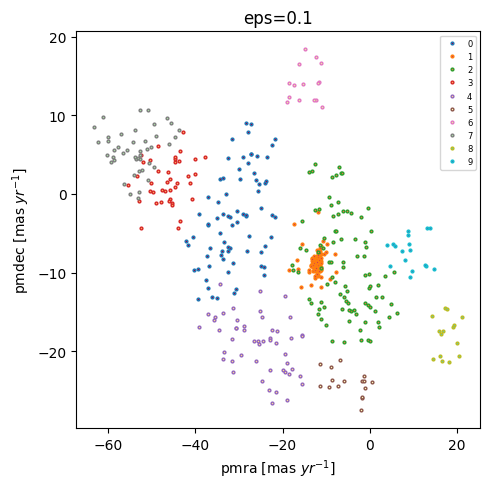

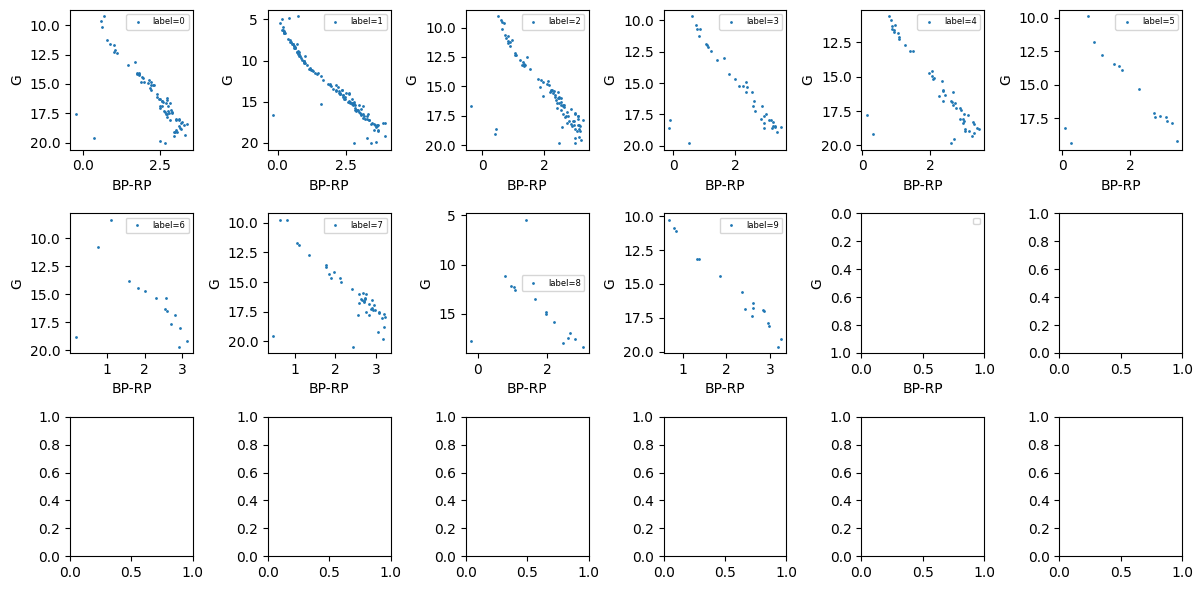

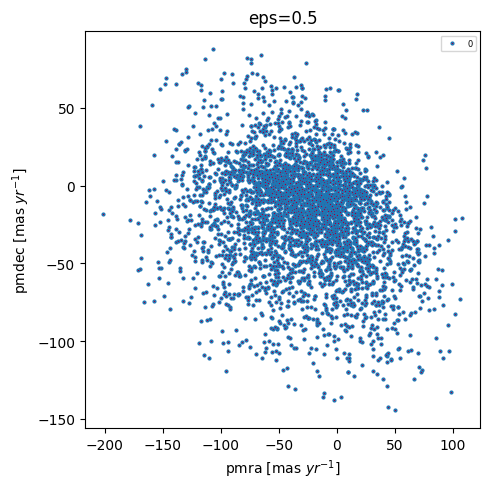

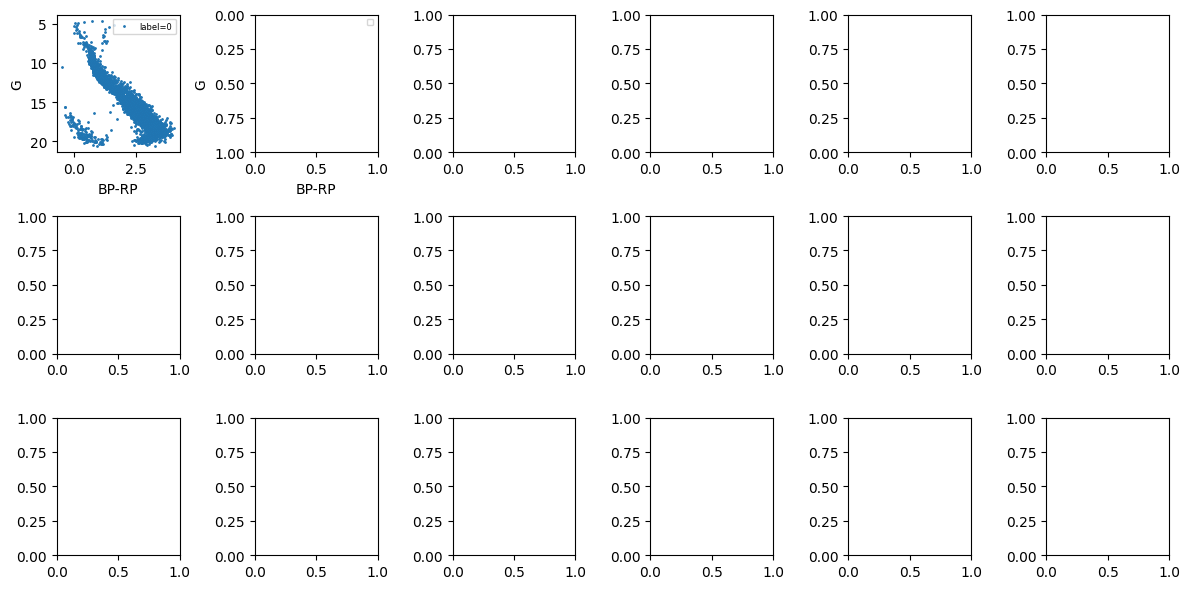

In [9]:
for eps_ in eps_grid:

    db = DBSCAN(eps=eps_, min_samples=15).fit(data) # n_jobs=-1

    labels = db.labels_
    df['label_db'] = labels

    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

    plt.figure(figsize=(5,5))
    plt.title(f"eps={eps_}")
    for i, j in zip(list(unique_labels), colors):
        if i != -1:
            plt.plot(df['pmra'][(df['label_db'] == i)], df['pmdec'][(df['label_db'] == i)], label=f"{i}",
            markerfacecolor=tuple(j), marker = 'o', linestyle='None',markersize=2, alpha=1)
    plt.xlabel("pmra [mas $yr^{-1}$]")
    plt.ylabel("pmdec [mas $yr^{-1}$]")
    plt.legend(fontsize=6)
    plt.tight_layout()
    plt.show() 


    fig, axes = plt.subplots(3, 6, figsize=(12,6))
    for i, j, ax in zip(list(unique_labels), colors, axes.flat):
        if i != -1:
            condition = (df['label_db'] == i)
            ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
            markerfacecolor = tuple(j),marker = 'o', linestyle='None', markersize=1, label=f'label={i}')
        ax.set_xlabel("BP-RP")
        ax.set_ylabel("G")
        ax.invert_yaxis()
        ax.legend(fontsize=6)

    fig.tight_layout()
    plt.show() 

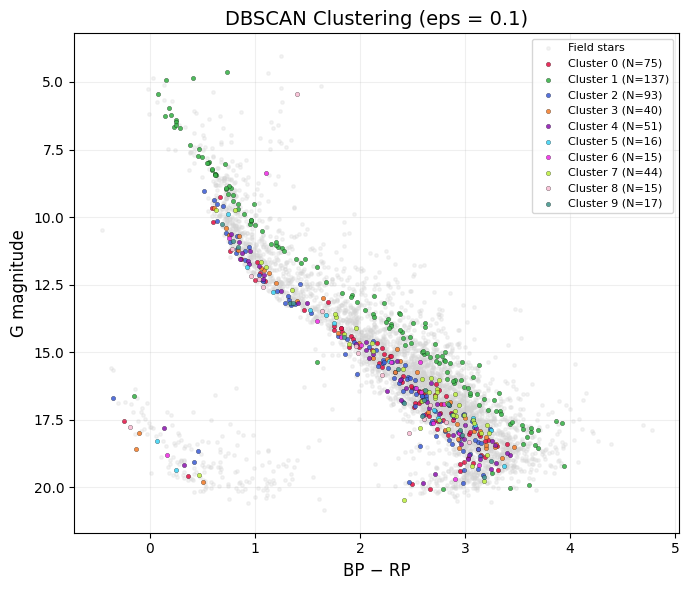

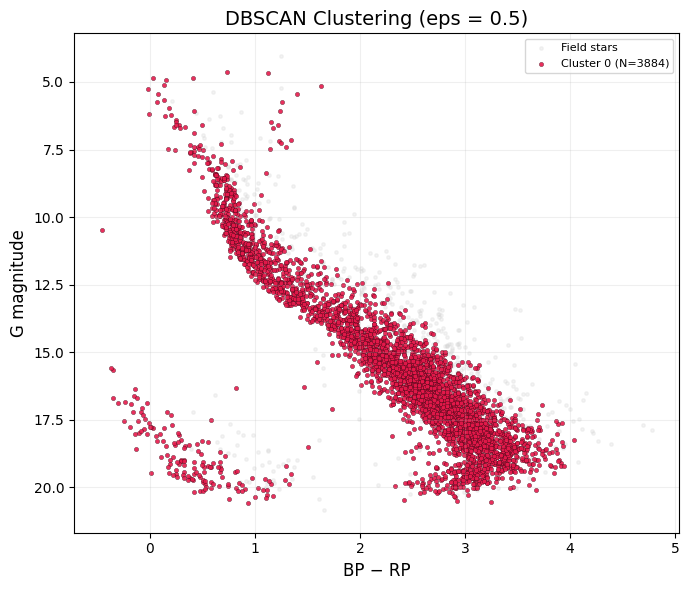

In [10]:
for eps_ in eps_grid:

    db = DBSCAN(eps=eps_, min_samples=15).fit(data)

    labels = db.labels_
    df['label_db'] = labels

    unique_labels = set(labels)

    plt.figure(figsize=(7,6))
    plt.title(f"DBSCAN Clustering (eps = {eps_})", fontsize=14)

    # --- Campo estelar (ruido) ---
    noise_mask = df['label_db'] == -1

    plt.scatter(
        (df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'])[noise_mask],
        df['phot_g_mean_mag'][noise_mask],
        s=6,
        color='lightgray',
        alpha=0.25,
        label="Field stars"
    )

    # --- Colormap para clusters ---
    colors_list = [
         '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
        '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990',
     '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3'
    ]
    colors = colors_list[:len(unique_labels)]

    for i, col in zip(unique_labels, colors):

        if i == -1:
            continue

        mask = df['label_db'] == i
        n_stars = np.sum(mask)

        plt.scatter(
            (df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'])[mask],
            df['phot_g_mean_mag'][mask],
            s=10,
            color=col,
            edgecolor='black',
            linewidth=0.2,
            alpha=0.9,
            label=f"Cluster {i} (N={n_stars})"
        )

    plt.xlabel("BP − RP", fontsize=12)
    plt.ylabel("G magnitude", fontsize=12)

    plt.grid(alpha=0.2)

    plt.legend(fontsize=8)

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

In [11]:
for lbl in set(labels):
    if lbl == -1: continue
    mask = labels == lbl
    pmra_m  = df['pmra'].values[mask].mean()
    pmdec_m = df['pmdec'].values[mask].mean()
    plx_m   = df['parallax'].values[mask].mean()
    
    es_coma = (-14 < pmra_m < -10) and (-11 < pmdec_m < -6) and (9 < plx_m < 14)
    marca = " ← COMA" if es_coma else ""
    print(f"Clúster {lbl:2d}: N={mask.sum():4d} | pmra={pmra_m:7.2f} | pmdec={pmdec_m:7.2f} | plx={plx_m:6.3f}{marca}")

Clúster  0: N=3884 | pmra= -28.82 | pmdec= -19.30 | plx= 7.080


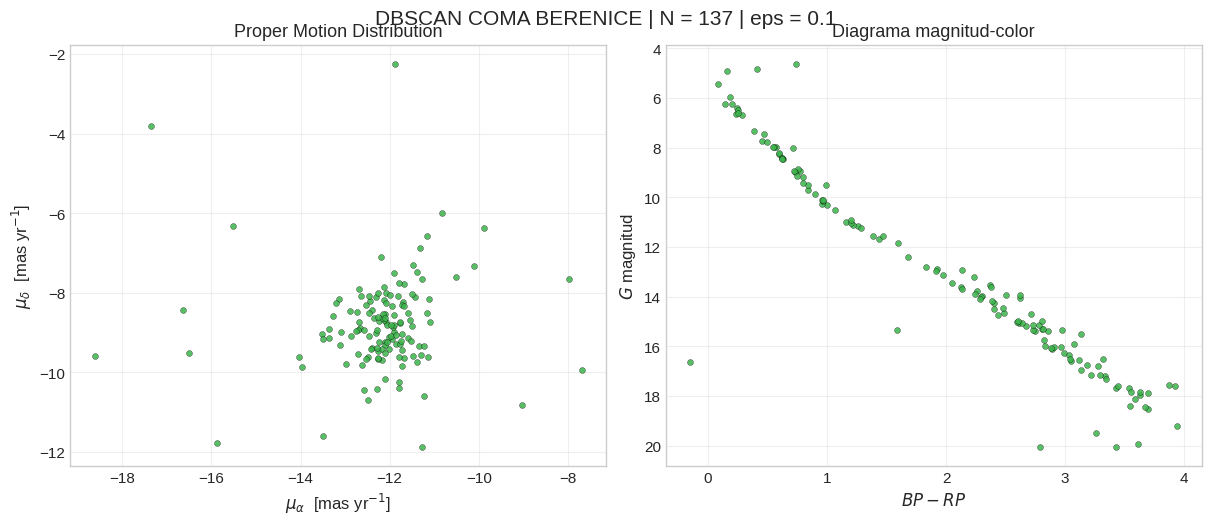

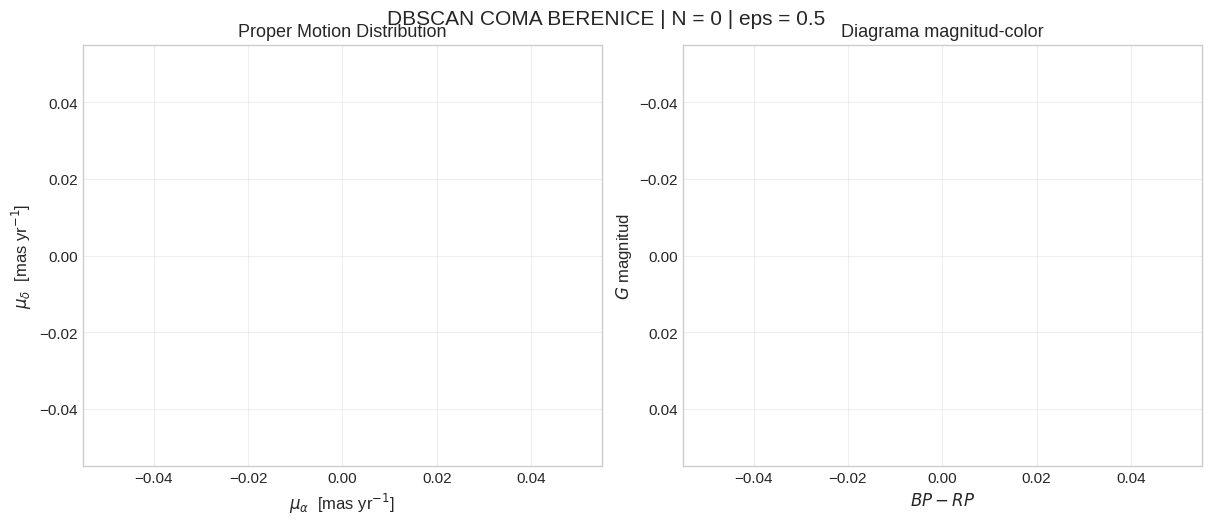

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")

for eps_ in eps_grid:

    db = DBSCAN(eps=eps_, min_samples=15).fit(data)

    labels = db.labels_
    df['label_db'] = labels

    mask = df['label_db'] == 1
    n_stars = np.sum(mask)

    color = "#3cb44b"

    fig, ax = plt.subplots(
        1, 2,
        figsize=(12,5),
        constrained_layout=True
    )

    # ---------- Proper Motion ----------
    ax[0].scatter(
        df['pmra'][mask],
        df['pmdec'][mask],
        s=18,
        color=color,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.85
    )

    ax[0].set_xlabel(r"$\mu_{\alpha}$  [mas yr$^{-1}$]", fontsize=12)
    ax[0].set_ylabel(r"$\mu_{\delta}$  [mas yr$^{-1}$]", fontsize=12)

    ax[0].set_title("Proper Motion Distribution", fontsize=13)

    ax[0].tick_params(labelsize=11)

    ax[0].grid(True, alpha=0.3)


    # ---------- CMD ----------
    ax[1].scatter(
        (df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'])[mask],
        df['phot_g_mean_mag'][mask],
        s=18,
        color=color,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.85
    )

    ax[1].set_xlabel(r"$BP-RP$", fontsize=12)
    ax[1].set_ylabel(r"$G$ magnitud", fontsize=12)

    ax[1].invert_yaxis()

    ax[1].set_title("Diagrama magnitud-color", fontsize=13)

    ax[1].tick_params(labelsize=11)

    ax[1].grid(True, alpha=0.3)


    # ---------- Título general ----------
    fig.suptitle(
        f"DBSCAN COMA BERENICE | N = {n_stars} | eps = {eps_}",
        fontsize=15,
        y=1.02
    )

    # ---------- Guardar para LaTeX ----------
    plt.savefig(
        "COMADB.pdf",
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()

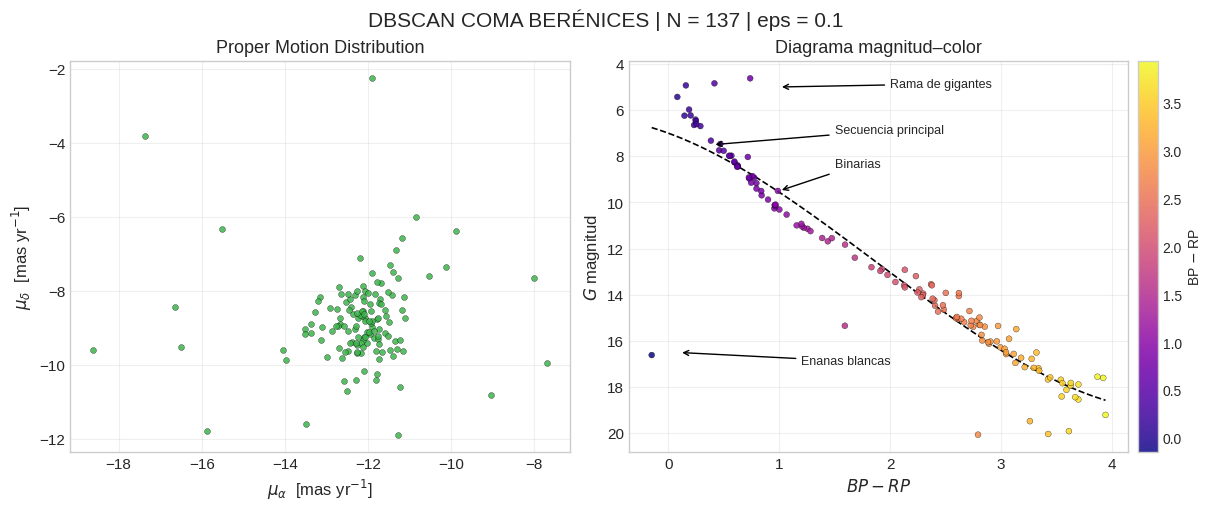

TypeError: expected non-empty vector for x

In [38]:
plt.style.use("seaborn-v0_8-whitegrid")

for eps_ in eps_grid:
    db = DBSCAN(eps=eps_, min_samples=15).fit(data)
    labels = db.labels_
    df['label_db'] = labels

    mask = df['label_db'] == 1
    n_stars = np.sum(mask)

    # ---- limpiar NaN ----
    bp_rp = (df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'])[mask]
    g_mag = df['phot_g_mean_mag'][mask]
    valid = np.isfinite(bp_rp) & np.isfinite(g_mag)
    bp_rp_clean = bp_rp[valid]
    g_mag_clean = g_mag[valid]

    # ---- ajuste polinomial ----
    coeffs = np.polyfit(bp_rp_clean, g_mag_clean, 3)
    p = np.poly1d(coeffs)
    x_fit = np.linspace(bp_rp_clean.min(), bp_rp_clean.max(), 300)
    y_fit = p(x_fit)

    color = "#3cb44b"
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # ---------- Proper Motion ----------
    ax[0].scatter(
        df['pmra'][mask],
        df['pmdec'][mask],
        s=18,
        color=color,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.85
    )
    ax[0].set_xlabel(r"$\mu_{\alpha}$  [mas yr$^{-1}$]", fontsize=12)
    ax[0].set_ylabel(r"$\mu_{\delta}$  [mas yr$^{-1}$]", fontsize=12)
    ax[0].set_title("Proper Motion Distribution", fontsize=13)
    ax[0].tick_params(labelsize=11)
    ax[0].grid(True, alpha=0.3)

    # ---------- CMD ----------
    sc = ax[1].scatter(
        bp_rp_clean,
        g_mag_clean,
        c=bp_rp_clean,
        cmap='plasma',
        s=18,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.25,
        zorder=3
    )
    ax[1].plot(x_fit, y_fit, 'k--', linewidth=1.2, zorder=2)
    ax[1].annotate('Binarias',
        xy=(1, 9.5), xytext=(1.5, 8.5), fontsize=9,
        arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    ax[1].annotate('Enanas blancas',
        xy=(0.1, 16.5), xytext=(1.2, 17.0), fontsize=9,
        arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    ax[1].annotate('Secuencia principal',
        xy=(0.4, 7.5), xytext=(1.5, 7.0), fontsize=9,
        arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    ax[1].annotate('Rama de gigantes',
        xy=(1, 5), xytext=(2, 5), fontsize=9,
        arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    fig.colorbar(sc, ax=ax[1], pad=0.02, label='BP $-$ RP')
    ax[1].set_xlabel(r"$BP-RP$", fontsize=12)
    ax[1].set_ylabel(r"$G$ magnitud", fontsize=12)
    ax[1].invert_yaxis()
    ax[1].set_title("Diagrama magnitud–color", fontsize=13)
    ax[1].tick_params(labelsize=11)
    ax[1].grid(True, alpha=0.3)

    # ---------- Título general ----------
    fig.suptitle(
        f"DBSCAN COMA BERÉNICES | N = {n_stars} | eps = {eps_}",
        fontsize=15
    )

    plt.savefig("COMADB.pdf", dpi=400, bbox_inches="tight")
    plt.show()

In [13]:
for lbl in set(labels):
    if lbl == -1: continue
    mask = labels == lbl
    pmra_m  = df['pmra'].values[mask].mean()
    pmdec_m = df['pmdec'].values[mask].mean()
    plx_m   = df['parallax'].values[mask].mean()
    print(f"Clúster {lbl}: N={mask.sum()} | pmra={pmra_m:.2f} | pmdec={pmdec_m:.2f} | plx={plx_m:.2f}")

Clúster 0: N=3884 | pmra=-28.82 | pmdec=-19.30 | plx=7.08


<div align="center">

# HDBSCAN

</div>

* Compute the core distance1 for the k nearest neighbors for all points in the set
* Compute the extended minimum spanning tree from a weighted graph, where the mutual reachability distances2 are the edges
* Build the HDBSCAN hierarchy from the extended minimum spanning tree
* Find the prominent clusters from the hierarchy

<div align="center">

<div align="center">
<img src="../images/hdbscan.png" alt="membership" width="1200"/>
</div>

Schematic representation of HDBSCAN (Campello+2013)
</div>

* k(i) = distance from i to its kth nearest neighbor
* dmr(i,j) = max{k(i), k(j), d(I,j) if i≠j}; 0 if i=j


### HDBSCAN Hyperparameters  

- **`min_cluster_size`:**  
  Minimum number of points needed to form a cluster. Smaller values detect smaller clusters.  

- **`min_samples`:**  
  Controls how conservative the clustering is. Higher values make clusters more robust to noise.  

- **`cluster_selection_epsilon`:**  
  A distance threshold for merging clusters. Works similarly to `eps` in DBSCAN.  

- **`metric`:**  
  Distance metric used to compute point similarity (default: `'euclidean'`).  

- **`cluster_selection_method`:**  
  Determines how clusters are extracted (`'eom'` for excess of mass, `'leaf'` for leaf clusters).  

- **`alpha`:**  
  Controls the relative importance of density-based and distance-based clustering.  

- **`leaf_size`:**  
  Affects the speed of KD-tree and Ball-tree nearest neighbor searches.  

- **`core_dist_n_jobs`:**  
  Number of parallel jobs for computing core distances (`-1` uses all processors).  


In [14]:
#hd = HDBSCAN(min_cluster_size=20, min_samples=5, metric='mahalanobis', metric_params={'V': np.cov(data, rowvar=False)}).fit(data)
hd = HDBSCAN(min_cluster_size=100, min_samples=10, metric='euclidean').fit(data)

In [15]:
labels = hd.labels_ 
df['label_hb'] = labels
for i in list(set(labels)):
    print('{} {}'.format(i,len(df[(df['label_hb'] == i)])))

0 2650
1 151
-1 1682


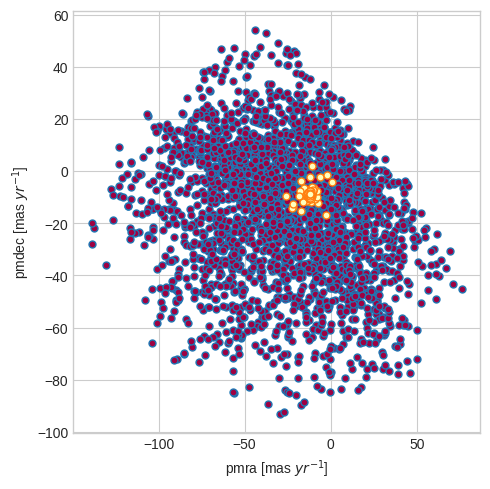

In [16]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (df['label_hb'] == i)
        plt.plot(df['pmra'][condition], df['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1)
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.show() 

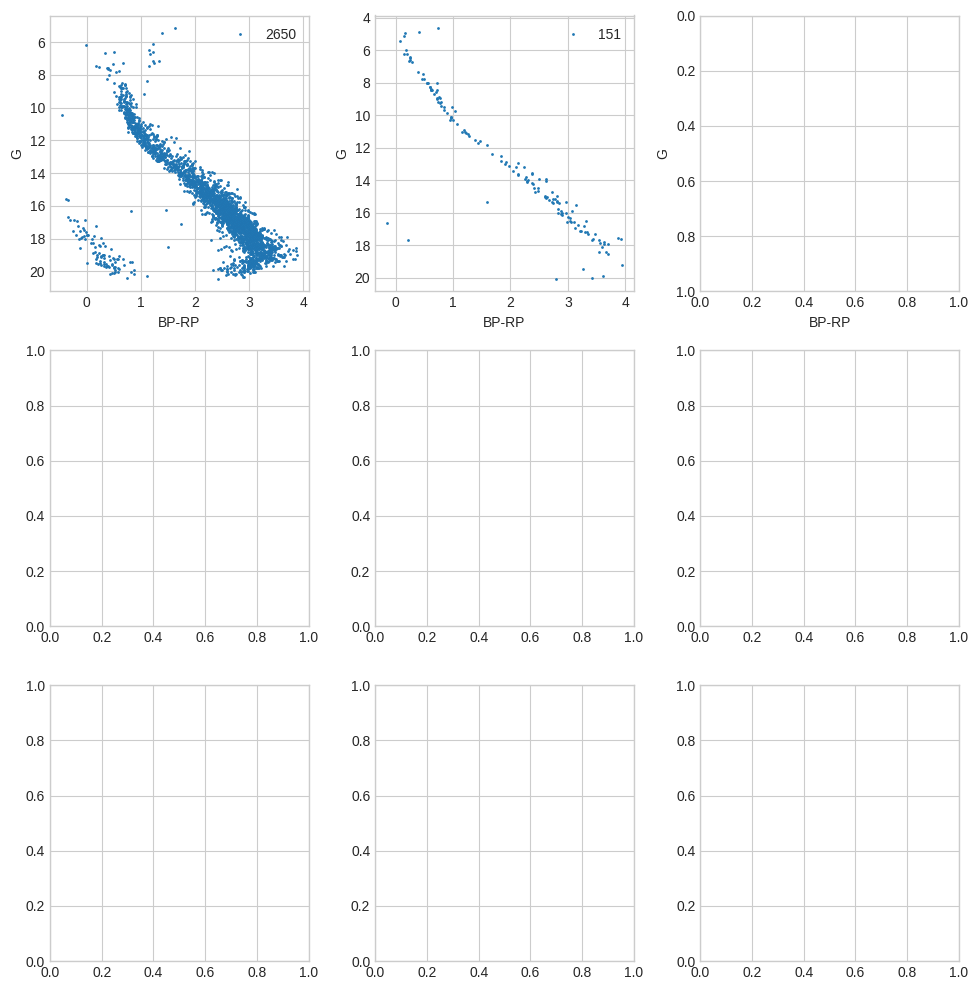

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df['label_hb'] == i)
        ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
         markerfacecolor = tuple(j), marker='o', linestyle='None', markersize=1, label=f'{len(df[condition])}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()

fig.tight_layout()
plt.show() 

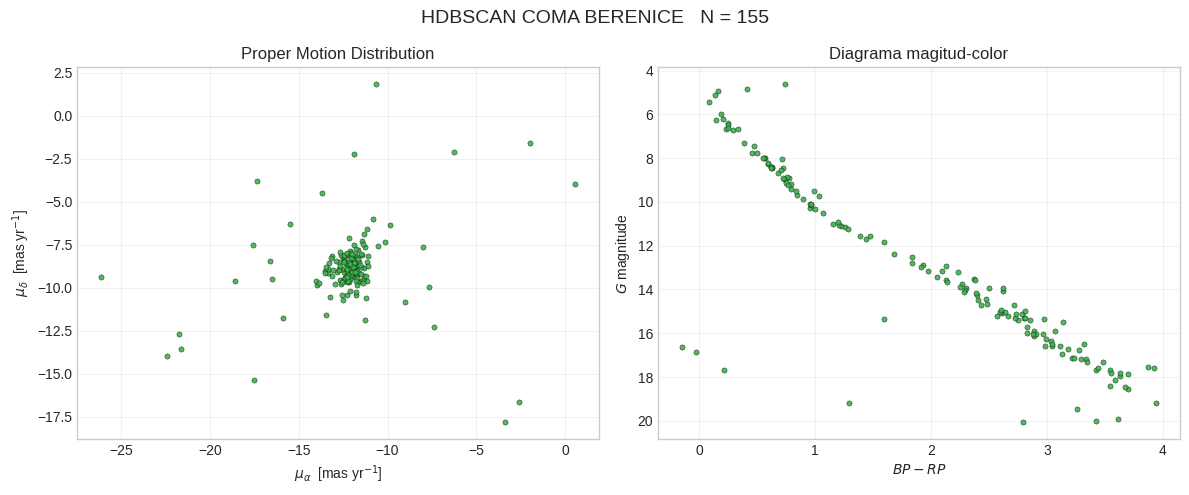

In [23]:
from hdbscan import HDBSCAN

# ---- correr HDBSCAN ----
hd = HDBSCAN(min_cluster_size=100, min_samples=10, metric='euclidean').fit(data)

labels = hd.labels_
df['label_hd'] = labels

# ---- seleccionar solo cluster 1 ----
mask = df['label_hd'] == 0
n_stars = np.sum(mask)

color = "#3cb44b"

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# -------- Proper Motions --------
ax[0].scatter(
    df['pmra'][mask],
    df['pmdec'][mask],
    s=14,
    color=color,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9
)

ax[0].set_xlabel(r"$\mu_{\alpha}$  [mas yr$^{-1}$]")
ax[0].set_ylabel(r"$\mu_{\delta}$  [mas yr$^{-1}$]")
ax[0].set_title("Proper Motion Distribution")

ax[0].grid(True, alpha=0.25)

# -------- CMD --------
ax[1].scatter(
    (df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'])[mask],
    df['phot_g_mean_mag'][mask],
    s=14,
    color=color,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9
)

ax[1].set_xlabel(r"$BP - RP$")
ax[1].set_ylabel(r"$G$ magnitude")

ax[1].invert_yaxis()

ax[1].set_title("Diagrama magitud-color")

ax[1].grid(True, alpha=0.25)

fig.suptitle(
    f"HDBSCAN COMA BERENICE   N = {n_stars}",
    fontsize=14
)

plt.tight_layout()

plt.savefig("COMAHD.png", dpi=300)

#fig.colorbar( label="Parallax [mas]")

plt.show()


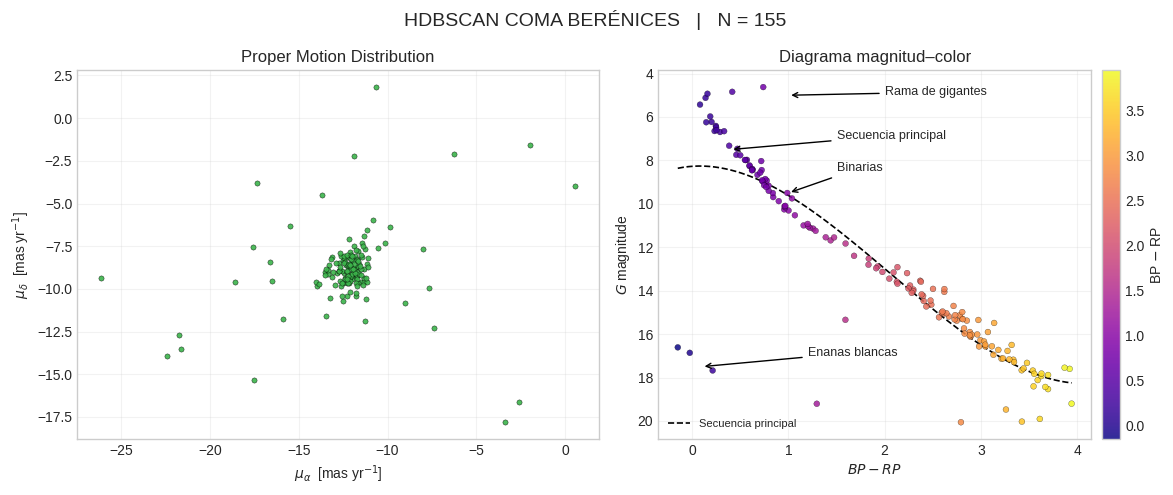

In [36]:
from hdbscan import HDBSCAN

# ---- correr HDBSCAN ----
hd = HDBSCAN(min_cluster_size=100, min_samples=10, metric='euclidean').fit(data)
labels = hd.labels_
df['label_hd'] = labels

# ---- seleccionar cluster ----
mask = df['label_hd'] == 0
n_stars = np.sum(mask)

# ---- limpiar NaN ----
bp_rp = (df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'])[mask]
g_mag = df['phot_g_mean_mag'][mask]
valid = np.isfinite(bp_rp) & np.isfinite(g_mag)
bp_rp_clean = bp_rp[valid]
g_mag_clean = g_mag[valid]


coeffs = np.polyfit(bp_rp_clean, g_mag_clean, 3)
p = np.poly1d(coeffs)
x_fit = np.linspace(bp_rp_clean.min(), bp_rp_clean.max(), 300)
y_fit = p(x_fit)

color = "#3cb44b"
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# -------- Proper Motions --------
ax[0].scatter(
    df['pmra'][mask],
    df['pmdec'][mask],
    s=14,
    color=color,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9
)
ax[0].set_xlabel(r"$\mu_{\alpha}$  [mas yr$^{-1}$]")
ax[0].set_ylabel(r"$\mu_{\delta}$  [mas yr$^{-1}$]")
ax[0].set_title("Proper Motion Distribution")
ax[0].grid(True, alpha=0.25)

# -------- CMD --------
sc = ax[1].scatter(
    bp_rp_clean,
    g_mag_clean,
    c=bp_rp_clean,
    cmap='plasma',
    s=18,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.2,
    zorder=3
)
ax[1].plot(x_fit, y_fit, 'k--', linewidth=1.2, label='Secuencia principal', zorder=2)
ax[1].annotate('Binarias',
    xy=(1, 9.5), xytext=(1.5, 8.5), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
ax[1].annotate('Enanas blancas',
    xy=(0.1, 17.5), xytext=(1.2, 17.0), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
ax[1].annotate('Secuencia principal',
    xy=(0.4, 7.5), xytext=(1.5, 7.0), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
ax[1].annotate('Rama de gigantes',
    xy=(1, 5), xytext=(2, 5), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
fig.colorbar(sc, ax=ax[1], pad=0.02, label='BP $-$ RP')
ax[1].set_xlabel(r"$BP - RP$")
ax[1].set_ylabel(r"$G$ magnitude")
ax[1].invert_yaxis()
ax[1].set_title("Diagrama magnitud–color")
ax[1].grid(True, alpha=0.25)
ax[1].legend(fontsize=8)

fig.suptitle(f"HDBSCAN COMA BERÉNICES   |   N = {n_stars}", fontsize=14)
plt.tight_layout()
plt.savefig("COMAHD.png", dpi=300, bbox_inches='tight')
plt.show()